<a href="https://colab.research.google.com/github/Prem8185/nids-streamlit-project/blob/main/network_intrusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After mounting your Google Drive, you can save the uploaded file(s) to a location within your Drive. This example saves all uploaded files into a folder named `Colab_Uploads` in your root Drive directory. You can change the `save_path` to any desired location.

In [ ]:
import os

# Define the path in Google Drive where you want to save the files
save_folder = '/content/drive/MyDrive/Colab_Uploads'

# Create the folder if it doesn't exist
os.makedirs(save_folder, exist_ok=True)

# Assuming 'uploaded' contains the files from files.upload()
# Iterate through the uploaded dictionary and save each file
for filename, content in uploaded.items():
    file_path = os.path.join(save_folder, filename)
    with open(file_path, 'wb') as f:
        f.write(content)
    print(f"File '{filename}' saved to '{file_path}'")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv("KDDTrain+.csv",header=None)

dataset.head()

In [ ]:
dataset.shape

(125973, 43)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       125973 non-null  int64  
 1   1       125973 non-null  object 
 2   2       125973 non-null  object 
 3   3       125973 non-null  object 
 4   4       125973 non-null  int64  
 5   5       125973 non-null  int64  
 6   6       125973 non-null  int64  
 7   7       125973 non-null  int64  
 8   8       125973 non-null  int64  
 9   9       125973 non-null  int64  
 10  10      125973 non-null  int64  
 11  11      125973 non-null  int64  
 12  12      125973 non-null  int64  
 13  13      125973 non-null  int64  
 14  14      125973 non-null  int64  
 15  15      125973 non-null  int64  
 16  16      125973 non-null  int64  
 17  17      125973 non-null  int64  
 18  18      125973 non-null  int64  
 19  19      125973 non-null  int64  
 20  20      125973 non-null  int64  
 21  21      12

In [ ]:
dataset.describe()

,0,4,5,6,7,8,9,10,11,12,...,32,33,34,35,36,37,38,39,40,42
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [ ]:
x = dataset.iloc[:,0:-2].values

y = dataset.iloc[:,41].values

print(x)

print(y)

[[0 'tcp' 'ftp_data' ... 0.0 0.05 0.0]
 [0 'udp' 'other' ... 0.0 0.0 0.0]
 [0 'tcp' 'private' ... 1.0 0.0 0.0]
 ...
 [0 'tcp' 'smtp' ... 0.0 0.01 0.0]
 [0 'tcp' 'klogin' ... 1.0 0.0 0.0]
 [0 'tcp' 'ftp_data' ... 0.0 0.0 0.0]]
['normal' 'normal' 'neptune' ... 'normal' 'neptune' 'normal']


In [ ]:
dos = ['back',
       'land',
       'neptune',
       'pod',
       'smurf',
       'teardrop']

probe = ['ipsweep',
         'nmap',
         'portsweep',
         'satan']

r2l = ['ftp_write',
       'guess_passwd',
       'imap',
       'multihop',
       'phf',
       'spy',
       'warezclient',
       'warezmaster']

u2r = ['buffer_overflow',
       'loadmodule',
       'perl',
       'rootkit']

In [ ]:
attack_class = []

for i in y:

    if i == 'normal':
        attack_class.append('Normal')

    elif i in dos:
        attack_class.append('DoS')

    elif i in probe:
        attack_class.append('Probe')

    elif i in r2l:
        attack_class.append('R2L')

    elif i in u2r:
        attack_class.append('U2R')

    else:
        attack_class.append('Other')

In [ ]:
y = np.array(attack_class)

print(y)

['Normal' 'Normal' 'DoS' ... 'Normal' 'DoS' 'Normal']


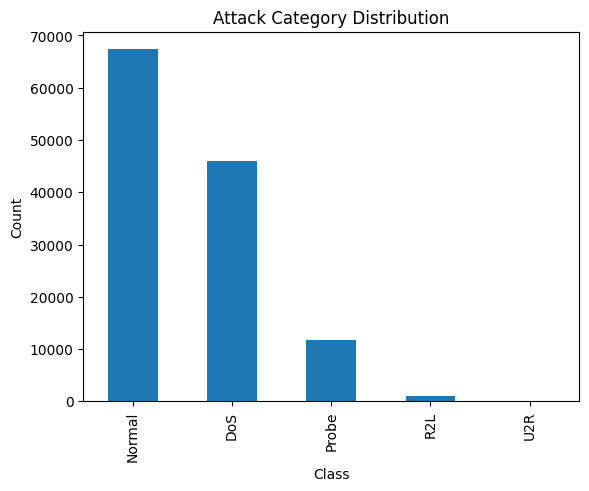

In [ ]:
pd.Series(y).value_counts().plot(kind='bar')

plt.title("Attack Category Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    [('encoder',OneHotEncoder(),[1,2,3])],
    remainder='passthrough'
)

x = np.array(ct.fit_transform(x))

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(y)

[1 1 0 ... 1 0 1]


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)

x_test = sc.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(
    max_iter=1000,
    random_state=0
)

classifier.fit(x_train,y_train)

LogisticRegression(max_iter=1000, random_state=0)

In [ ]:
y_pred = classifier.predict(x_test)

print(y_pred)

[1 1 1 ... 2 0 1]


In [ ]:
print(y_test)

[1 1 1 ... 2 0 1]


In [ ]:
df = pd.DataFrame()

df['y_actual'] = y_test

df['y_pred'] = y_pred

print(df)

       y_actual  y_pred
0             1       1
1             1       1
2             1       1
3             0       0
4             2       2
...         ...     ...
25190         1       1
25191         1       1
25192         2       2
25193         0       0
25194         1       1

[25195 rows x 2 columns]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy =",accuracy*100,"%")

Accuracy = 98.88073030363167 %


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9166
           1       0.99      0.99      0.99     13457
           2       0.98      0.96      0.97      2342
           3       0.81      0.81      0.81       215
           4       0.78      0.47      0.58        15

    accuracy                           0.99     25195
   macro avg       0.91      0.85      0.87     25195
weighted avg       0.99      0.99      0.99     25195



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

classifier.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred = classifier.predict(x_test)

print(y_pred)

[1 1 1 ... 2 0 1]


In [ ]:
from sklearn.metrics import accuracy_score

knn_acc = accuracy_score(y_test,y_pred)

print("Accuracy =",knn_acc*100,"%")

Accuracy = 99.36098432228617 %


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[ 9154    12     0     0     0]
 [    6 13421    18     9     3]
 [   44    31  2267     0     0]
 [    0    26     3   186     0]
 [    0     9     0     0     6]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      9166
           1       0.99      1.00      1.00     13457
           2       0.99      0.97      0.98      2342
           3       0.95      0.87      0.91       215
           4       0.67      0.40      0.50        15

    accuracy                           0.99     25195
   macro avg       0.92      0.85      0.88     25195
weighted avg       0.99      0.99      0.99     25195



In [ ]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(
    criterion='entropy',
    random_state=0
)

classifier.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
y_pred = classifier.predict(x_test)

In [ ]:
dt_acc = accuracy_score(y_test,y_pred)

print("Accuracy =",dt_acc*100,"%")

Accuracy = 99.78964080174639 %


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9166
           1       1.00      1.00      1.00     13457
           2       0.99      0.99      0.99      2342
           3       0.99      0.98      0.98       215
           4       0.60      0.60      0.60        15

    accuracy                           1.00     25195
   macro avg       0.92      0.91      0.91     25195
weighted avg       1.00      1.00      1.00     25195



In [ ]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=0
)

classifier.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', random_state=0)

In [ ]:
y_pred = classifier.predict(x_test)

In [ ]:
rf_acc = accuracy_score(y_test,y_pred)

print("Accuracy =",rf_acc*100,"%")

Accuracy = 99.88886683865846 %


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9166
           1       1.00      1.00      1.00     13457
           2       1.00      1.00      1.00      2342
           3       1.00      0.96      0.98       215
           4       0.90      0.60      0.72        15

    accuracy                           1.00     25195
   macro avg       0.98      0.91      0.94     25195
weighted avg       1.00      1.00      1.00     25195



In [ ]:
models = [
    'Logistic Regression',
    'KNN',
    'Decision Tree',
    'Random Forest'
]

accuracies = [
    accuracy*100,
    knn_acc*100,
    dt_acc*100,
    rf_acc*100
]

comparison = pd.DataFrame()

comparison['Model'] = models

comparison['Accuracy'] = accuracies

print(comparison)

                 Model   Accuracy
0  Logistic Regression  98.880730
1                  KNN  99.360984
2        Decision Tree  99.789641
3        Random Forest  99.888867


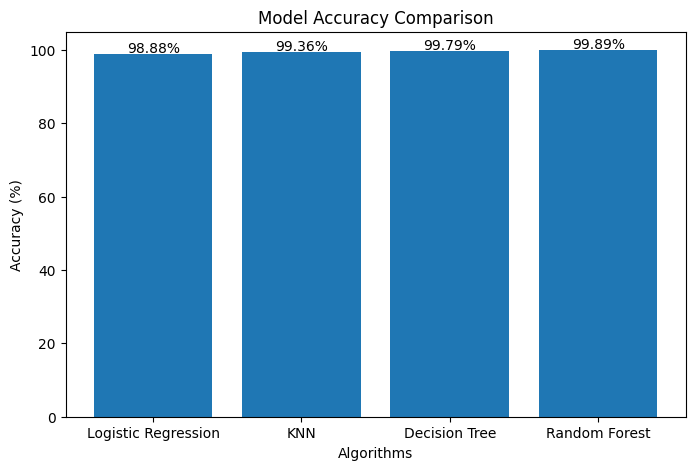

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.xlabel("Algorithms")

plt.ylabel("Accuracy (%)")

plt.ylim(0,105)

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5,
        f"{yval:.2f}%",
        ha='center'
    )

plt.show()

In [ ]:
import pickle

pickle.dump(classifier, open('model.pkl', 'wb'))

print("Model saved successfully")

Model saved successfully


In [ ]:
import pickle

pickle.dump(sc, open('scaler.pkl', 'wb'))

print("Scaler saved successfully")

Scaler saved successfully


In [ ]:
pickle.dump(le, open('label_encoder.pkl', 'wb'))

print("Label Encoder saved successfully")

Label Encoder saved successfully


In [ ]:
pickle.dump(ct, open('encoder.pkl', 'wb'))

print("Encoder saved successfully")

Encoder saved successfully


In [ ]:
import os

print(os.listdir())

['.config', 'label_encoder.pkl', 'KDDTrain+.csv', 'model.pkl', 'encoder.pkl', 'drive', 'scaler.pkl', 'sample_data']


In [ ]:
from google.colab import files

files.download('model.pkl')
files.download('scaler.pkl')
files.download('label_encoder.pkl')
files.download('encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>